In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [3]:
path = r"C:\Users\Noble Adike\Desktop\Coding\KPMG\kpmg-1a\data\harvard\Year 2 (Jun 2023 - May 2024)\Slab_temp_hourly\48190909_Slab_temp_hourly.csv"
df = pd.read_csv(path)
df.head()

,Timestamp,Z11_temp,Z12_temp,Z13_temp,Z14_temp,Z15_temp,Z16_temp,Z17_temp,Z1_temp,Z21_temp,...,Z23_temp,Z24_temp,Z25_temp,Z26_temp,Z27_temp,Z2_temp,Z31_temp,Z32_temp,Z33_temp,Z4_temp
0,2023-06-01 00:00:00-04:00,70.993997,71.491998,72.055994,72.223993,72.007993,71.569998,70.606997,70.603997,71.737999,...,71.707999,71.455997,71.419997,71.287994,71.581998,70.069996,72.133992,72.500000,73.417994,67.384999
1,2023-06-01 01:00:00-04:00,69.679995,69.679995,70.039996,71.056997,70.174996,70.309996,70.525997,69.715995,70.927997,...,70.525996,70.489996,70.633996,70.267996,70.123996,69.937996,71.941999,72.247995,71.671997,67.129999
2,2023-06-01 02:00:00-04:00,68.548995,68.056995,68.206995,69.715995,69.061994,68.869995,70.432996,68.896994,69.943996,...,69.037994,69.313995,69.511995,69.379995,68.839994,69.628995,71.707999,71.575997,69.913996,66.727994
3,2023-06-01 03:00:00-04:00,67.759996,67.105998,67.249998,68.809994,68.239996,67.975995,70.300996,68.302997,69.157994,...,68.095996,68.560996,68.704994,68.734994,68.065996,69.367995,71.518998,71.035995,68.776995,66.391997
4,2023-06-01 04:00:00-04:00,67.192999,66.478996,66.676995,68.125997,67.594995,67.336998,70.138996,67.843995,68.461996,...,67.399997,67.933994,68.038996,68.164997,67.435997,69.088994,71.269993,70.546997,67.969995,66.142997


In [4]:
df.describe()

,Z11_temp,Z12_temp,Z13_temp,Z14_temp,Z15_temp,Z16_temp,Z17_temp,Z1_temp,Z21_temp,Z22_temp,Z23_temp,Z24_temp,Z25_temp,Z26_temp,Z27_temp,Z2_temp,Z31_temp,Z32_temp,Z33_temp,Z4_temp
count,8727.000000,8576.000000,8754.000000,8769.000000,8752.000000,8769.000000,8769.000000,8769.000000,8769.000000,8769.000000,8753.000000,8756.000000,8769.000000,8755.000000,8769.000000,8769.000000,8756.000000,8743.000000,8769.000000,8416.000000
mean,70.090056,70.367502,70.503603,70.736389,70.577336,70.359792,69.094913,69.947982,70.627608,70.550394,70.494677,70.524500,70.472147,70.424737,70.471658,70.119068,71.324507,71.200581,71.142858,68.419104
std,2.173956,2.318368,2.211724,1.955866,2.102205,2.090787,1.339626,2.184874,2.133576,2.196524,2.216852,2.120764,2.253052,2.016573,2.164624,1.869522,1.652293,1.788171,2.485772,2.263440
min,64.198994,63.524000,64.219994,65.107995,64.219994,64.399994,64.219994,63.860001,64.771995,64.573994,64.399994,64.762995,64.798995,64.993995,64.855995,65.080995,66.019997,66.559998,63.967996,63.500000
25%,69.079994,69.800000,69.718995,70.087996,69.967996,69.259995,68.314999,68.284997,69.259995,69.442995,69.298995,69.361245,69.079994,69.259995,69.097994,68.767994,70.339996,70.125496,69.685995,66.781992
50%,70.513997,70.879997,70.879997,71.056997,71.005997,70.765997,68.899994,70.450997,71.053998,70.936997,70.873997,70.879997,70.768997,70.738997,70.855997,70.393996,71.364496,71.239990,71.266991,68.006000
75%,71.668999,71.959999,71.983998,72.013997,71.981748,71.836999,69.694995,71.494998,72.121992,72.052995,72.019997,72.002747,72.028996,71.904499,71.986996,71.467998,72.191742,72.433997,72.505996,70.519997
max,74.659996,74.839996,76.495998,75.721991,75.409997,74.692996,73.939995,74.827996,76.321999,78.619995,79.519997,76.279999,79.321996,76.267999,76.819992,74.455996,77.605994,76.795992,79.879997,73.399994


In [5]:
df.isna().sum()

Timestamp      0
Z11_temp      57
Z12_temp     208
Z13_temp      30
Z14_temp      15
Z15_temp      32
Z16_temp      15
Z17_temp      15
Z1_temp       15
Z21_temp      15
Z22_temp      15
Z23_temp      31
Z24_temp      28
Z25_temp      15
Z26_temp      29
Z27_temp      15
Z2_temp       15
Z31_temp      28
Z32_temp      41
Z33_temp      15
Z4_temp      368
dtype: int64

In [6]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.set_index('Timestamp')

C:\Users\Noble Adike\AppData\Local\Temp\ipykernel_16744\330094659.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


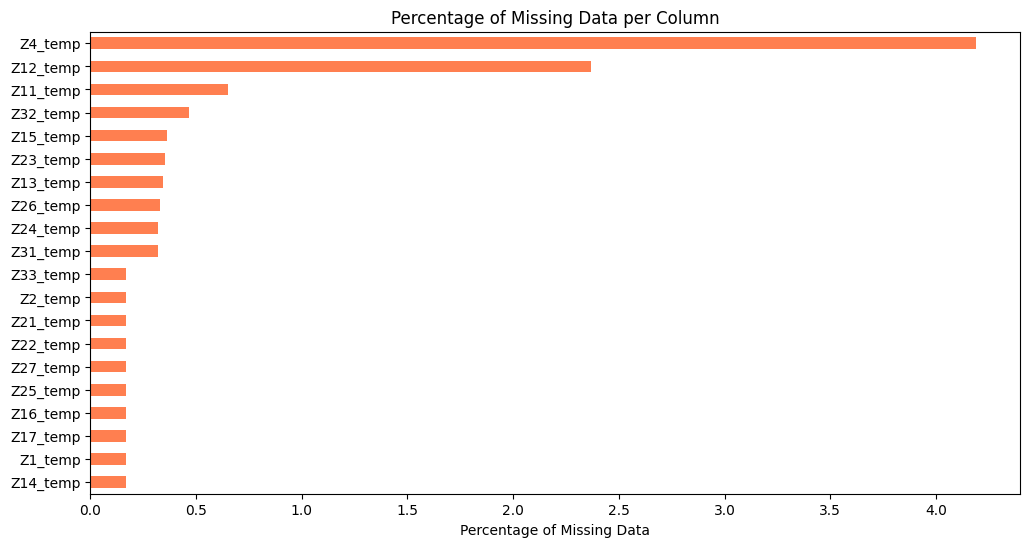

In [7]:
# 7. Distribution of Missing Data
# Missing values per column as percentage
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0]  # Only show columns with missing data
missing_percent.sort_values().plot(kind='barh', figsize=(12, 6), color='coral')
plt.title('Percentage of Missing Data per Column')
plt.xlabel('Percentage of Missing Data')
plt.show()

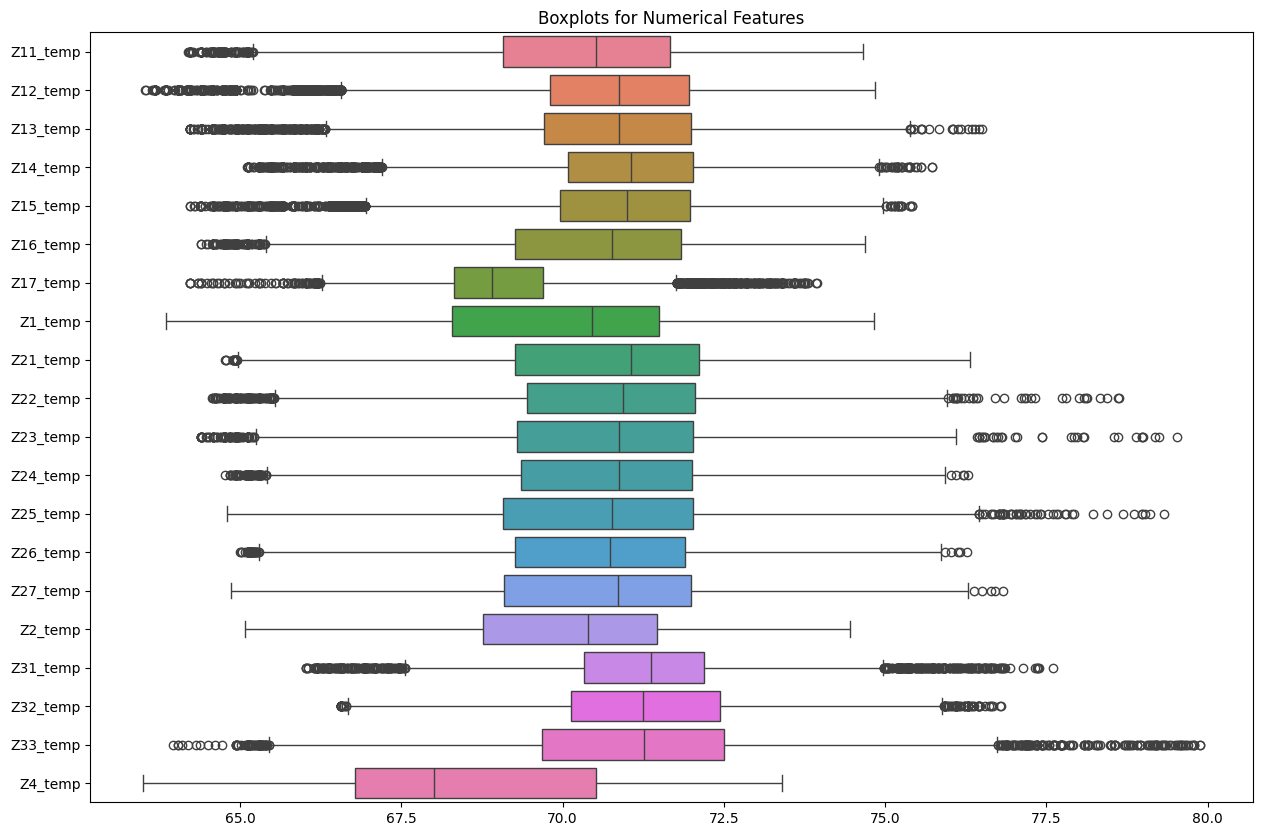

In [8]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df.select_dtypes(include=['float64', 'int64']), orient='h')
plt.title('Boxplots for Numerical Features')
plt.show()

In [9]:
#interpolation to handle gaps
df = df.interpolate(limit=5, limit_direction='both').ffill().bfill()

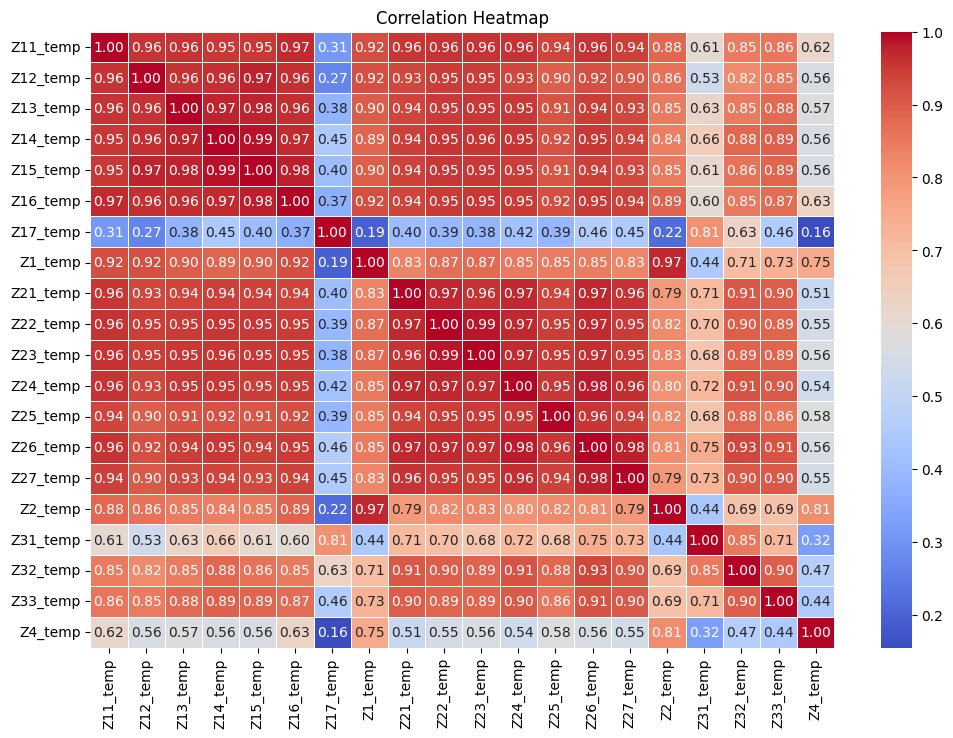

In [10]:
corr = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
def treat_outliers_iqr(df):
    df_clean = df.copy()
    for col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1


        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
    return df_clean
df = treat_outliers_iqr(df)

In [12]:
df.describe()

,Z11_temp,Z12_temp,Z13_temp,Z14_temp,Z15_temp,Z16_temp,Z17_temp,Z1_temp,Z21_temp,Z22_temp,Z23_temp,Z24_temp,Z25_temp,Z26_temp,Z27_temp,Z2_temp,Z31_temp,Z32_temp,Z33_temp,Z4_temp
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,70.090707,70.481293,70.545433,70.778808,70.650926,70.362721,69.065923,69.942369,70.622310,70.550448,70.487504,70.523126,70.461301,70.426433,70.466707,70.115141,71.321252,71.199328,71.116419,68.304629
std,2.149402,2.059603,2.098521,1.845965,1.928317,2.071459,1.226478,2.187223,2.135424,2.164368,2.188286,2.112848,2.238144,2.020829,2.165456,1.870336,1.551828,1.783780,2.415759,2.298980
min,65.209988,66.560001,66.279116,67.096619,66.941367,65.394488,66.252504,63.860001,64.970369,65.529494,65.191991,65.370117,64.798995,65.281988,64.855995,65.080995,67.557878,66.638369,65.404988,63.500000
25%,69.079994,69.800000,69.700245,70.045246,69.961996,69.259995,68.317999,68.266997,69.259995,69.439995,69.286995,69.349245,69.079994,69.259995,69.079994,68.749244,70.339996,70.117996,69.661995,66.739990
50%,70.501997,70.879997,70.879997,71.053998,71.007497,70.761497,68.899994,70.446497,71.053998,70.927997,70.867997,70.879997,70.761497,70.738997,70.851497,70.393996,71.365996,71.239990,71.263991,67.849993
75%,71.659999,71.959999,71.980998,72.010997,71.975748,71.836999,69.694995,71.491998,72.119745,72.046996,72.016997,72.001997,72.023746,71.911999,71.983997,71.464998,72.194742,72.437747,72.500000,70.339996
max,74.659996,74.839996,75.402127,74.959624,74.996377,74.692996,71.760490,74.827996,76.321999,75.957497,76.112000,75.981125,76.439375,75.890005,76.340001,74.455996,74.976860,75.917374,76.757007,73.399994


In [13]:
df.isna().sum()

Z11_temp    0
Z12_temp    0
Z13_temp    0
Z14_temp    0
Z15_temp    0
Z16_temp    0
Z17_temp    0
Z1_temp     0
Z21_temp    0
Z22_temp    0
Z23_temp    0
Z24_temp    0
Z25_temp    0
Z26_temp    0
Z27_temp    0
Z2_temp     0
Z31_temp    0
Z32_temp    0
Z33_temp    0
Z4_temp     0
dtype: int64